# Day 10: Non-Linear Models & Overfitting

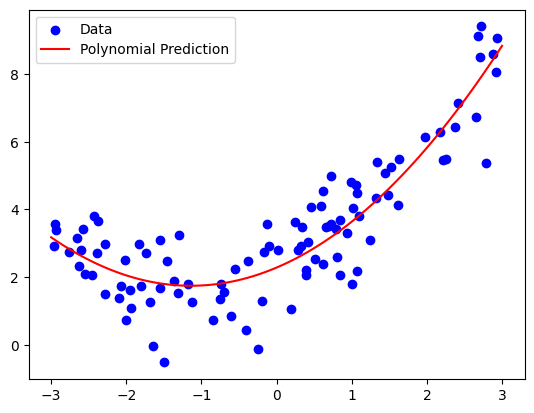

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# 1. Generate "Curvy" Synthetic Data
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)
# 2. Transform X to include X-squared
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
# 3. Fit Linear Regression to the "Squared" data
model = LinearRegression()
model.fit(X_poly, y)
# 4. Plotting the result
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = model.predict(X_new_poly)
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X_new, y_new, color='red', label='Polynomial Prediction')
plt.legend()
plt.show()

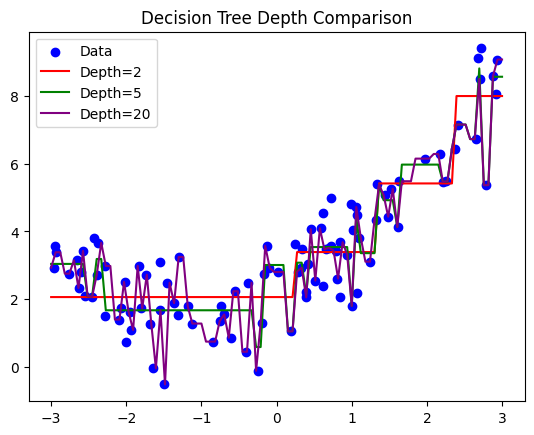

In [4]:
from sklearn.tree import DecisionTreeRegressor 

depths = [2, 5, 20]
colors = ['red', 'green', 'purple']  # different colors

plt.scatter(X, y, color='blue', label='Data')

for depth, color in zip(depths, colors):
    tree_reg = DecisionTreeRegressor(max_depth=depth) 
    tree_reg.fit(X, y) 
    
    y_tree_pred = tree_reg.predict(X_new) 
    
    plt.plot(X_new, y_tree_pred, color=color, label=f'Depth={depth}') 

plt.legend()
plt.title("Decision Tree Depth Comparison")
plt.show()


In [3]:
# Comparing R2 scores 
from sklearn.metrics import r2_score

# Polynomial score
y_poly_train = model.predict(X_poly)
print("Polynomial R2:", r2_score(y, y_poly_train))

# Tree score
y_tree_train = tree_reg.predict(X)
print("Decision Tree R2:", r2_score(y, y_tree_train))

Polynomial R2: 0.7994061220682075
Decision Tree R2: 1.0


## Reflection
### Why is a 'jittery' model that hits every training point actually worse for making future predictions than a smooth 'curvy' model?

A jittery model that perfectly fits every training point is a sign of overfitting, not true learning. It memorizes noise and small fluctuations instead of capturing the real pattern in the data. While it achieves very high accuracy on training data, it becomes unreliable for real-world use because new data will always differ.

In contrast, a smooth curvy model focuses on the overall relationship between input and output. By ignoring minor variations and noise, it generalizes better to unseen data and provides more reliable predictions.

This can be explained by the bias-variance tradeoff: very complex models have low bias but high variance, making them sensitive to small changes. Simpler models maintain a better balance, which is why a smooth model is more effective than a jittery one for future predictions
